# Fraud Detection

This notebook covers:
* Most stages of the ML lifecycle:
    * Data import, preprocessing, and exploration
    * Modeling and validation
    * Model registration and deployment
    * Deployment invocation
* Production-oriented model design:
    * Use of a scikit-learn pipeline
    * Custom deployment, where feature engineering is handled within the deployment (rather than ad hoc on the client side)
    * High cardinality of the categorical features

This is the main notebook, and it relies on helper functions from additional scripts.

Also, please note that the deployed model can be used for both real-time fraud monitoring and alerting, as well as batch monitoring. For batch monitoring, please refer to the automation folder.

Runtime:
generalml_p311_cpu_x86_64_v1\
Additional libraries were installed, including category_encoders and seaborn

Authour: Assaf Rabinowicz\
Date: May 2026

# Import packages and data

In [1]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import os

from config import FEATURE_SET
from feature import feature_engineering, add_iso_score, fit_iso_forest
from data import load_data_from_oci, split_column_types
from prepro import build_preprocessor
from model import build_model, build_pipeline, find_hyper_params, train_final_model
from analysis import compute_roc_metrics, get_feature_names, plot_feature_importance
from analysis import plot_roc_curve, plot_prop, plot_fraud_rate_by_category, plot_fraud_by_hour, plot_boxplot_by_fraud
from analysis import plot_shap_summary, compute_shap_values

In [3]:
import oci
import requests
from ads.model.generic_model import GenericModel
import ads
ads.set_auth(auth="resource_principal")

In [4]:
# data: https://www.kaggle.com/datasets/priyamchoksi/credit-card-transactions-dataset/data
# The data was split into two subsets which were stored in Object Storage, one of them is used here.
df = load_data_from_oci(
    "fraud-detection-bucket",
    "training_data_fraud_detection_kaggle_600.csv"
)

In [5]:
print('shape: ',df.shape)
df.head()

shape:  (648337, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,684365,2019-10-19 11:14:57,581508178315,fraud_Lynch Ltd,shopping_pos,131.60,Michael,Vargas,M,933 Martin Rapids,...,-98.5673,407,Clothing/textile technologist,1978-08-08,d4eabf36041cd28680705e9464315fc0,1350645297,31.742311,-97.657385,0,76634.0
1,1149936,2020-04-24 17:05:33,343464013864032,fraud_Swift PLC,kids_pets,57.89,Jodi,Foster,F,551 Zachary Freeway,...,-78.0892,6629,Call centre manager,1962-08-13,984a53297467db6fe61d0f24385cf13b,1366823133,34.848964,-78.966559,0,28384.0
2,716689,2019-11-02 15:21:13,30407675418785,fraud_Beer-Jast,kids_pets,43.41,Danielle,Evans,F,76752 David Lodge Apt. 064,...,-76.7361,520,Psychotherapist,1991-10-13,abf4b10688ee9113d59962edf57fea4b,1351869673,41.372683,-77.053554,0,17771.0
3,452599,2019-07-20 08:34:13,3523843138706408,fraud_Goodwin-Nitzsche,grocery_pos,105.59,Grace,Williams,F,28812 Charles Mill Apt. 628,...,-86.9475,1412,Drilling engineer,1970-11-20,f4e672cbab8f2699dfb2ba1661335c67,1342773253,32.272346,-87.328527,0,36773.0
4,805433,2019-12-05 19:42:10,30501624614310,fraud_Lemke-Gutmann,shopping_net,8.81,Amanda,Smith,F,180 Graves Shore,...,-81.2455,302,Magazine features editor,1973-05-04,2d7a8b9142a090601dfde837030006ce,1354736530,32.562262,-82.115629,0,30471.0


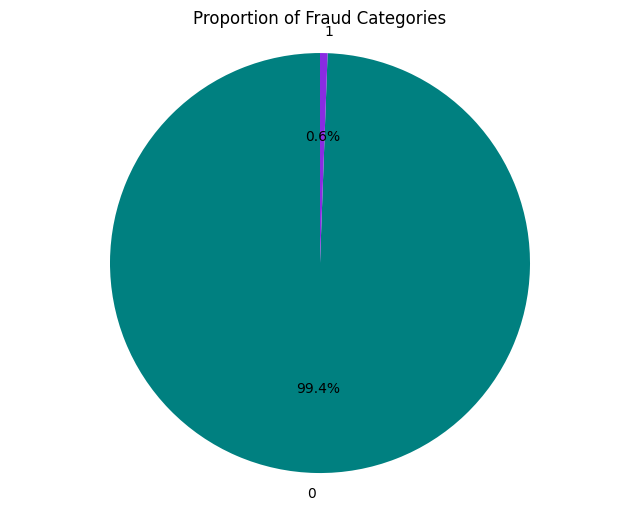

Class distribution:
is_fraud
0    644591
1      3746
Name: count, dtype: int64


In [6]:
plot_prop(df,'is_fraud')

* A low rate of anomalies is inherent to this type of problem, making modeling particularly challenging.
* Several approaches can help address this issue, for example, we later assign higher weights to anomalous cases.
* However, the most effective way to improve model performance is to increase the size of the dataset

# Data preprocessing

Feature engineering is particularly important in anomaly detection use cases, as it helps compensate for the scarcity of anomalous events.

Features can be engineered either through domain-driven logic or by leveraging algorithmic transformations. In this case, we created three additional features:
* Cardholder age – derived from the date of birth and the transaction timestamp
* Transaction hour – extracted from the transaction timestamp (trans_date_trans_time)
* Distance between the cardholder and the merchant – computed using their geographic coordinates

A commonly used algorithmic approach in anomaly detection is Isolation Forest

In [7]:
df = feature_engineering(df) # add the three new engineered features to the df
# Later, You can also add a feature based on Isolation Forest using the fit_iso_forest and add_iso_score functions in model.py, after defining X_train and numeric_cols.

In [8]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
scale_pos_weight_value = (len(y_train)-sum(y_train))/(sum(y_train)*10)

In [9]:
X_train = X_train[FEATURE_SET]
X_test = X_test[FEATURE_SET]

numeric_cols, low_card, high_card = split_column_types(X_train)
print(high_card)

['street', 'city', 'state', 'job']


In [10]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode', 'age', 'hour',
       'geo_dist'],
      dtype='object')

# Data Exploration

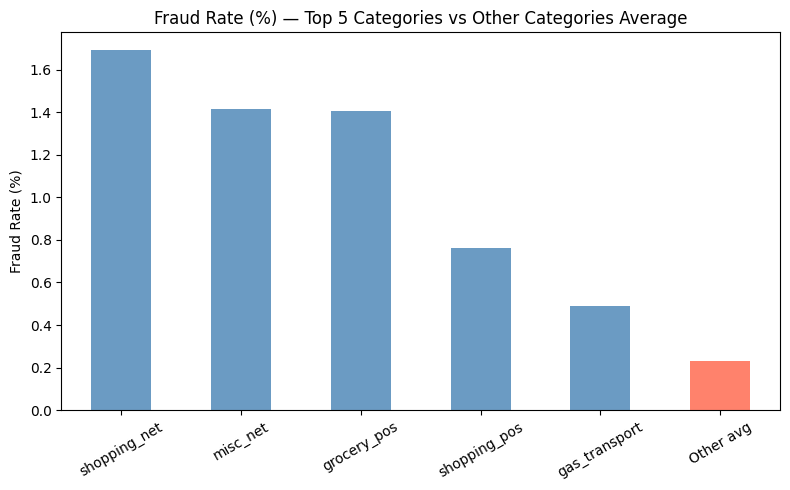

In [11]:
plot_fraud_rate_by_category(df)

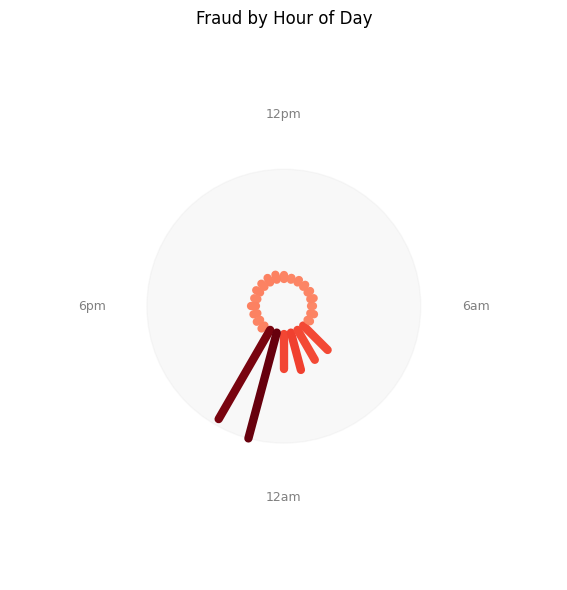

In [12]:
plot_fraud_by_hour(df)

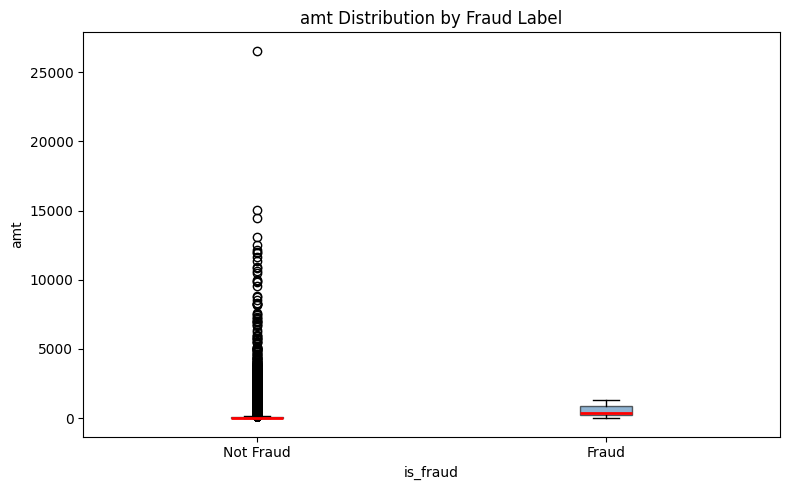

In [13]:
plot_boxplot_by_fraud(df, column='amt')

# Modeling

## Model pipeline

In [14]:
preprocessor = build_preprocessor(numeric_cols, low_card, high_card) # data transformer

In [15]:
model = build_model(scale_pos_weight_value)

## Hyperparameters Selection

In [16]:
pipeline = build_pipeline(preprocessor, model)
best_params = find_hyper_params(pipeline, X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


In [17]:
print(best_params)

{'subsample': 0.6, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.6}


## Final model pipeline

In [18]:
model_pipeline = train_final_model(X_train, y_train, best_params, preprocessor,scale_pos_weight_value)

In [19]:
model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('target', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

# Validation and Explainability

In [20]:
y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    128919
           1       0.70      0.78      0.74       749

    accuracy                           1.00    129668
   macro avg       0.85      0.89      0.87    129668
weighted avg       1.00      1.00      1.00    129668



The model correctly detects 77.3% of fraudulent transactions and correctly classifies 99.8% of non-fraudulent transactions as non-fraud. 

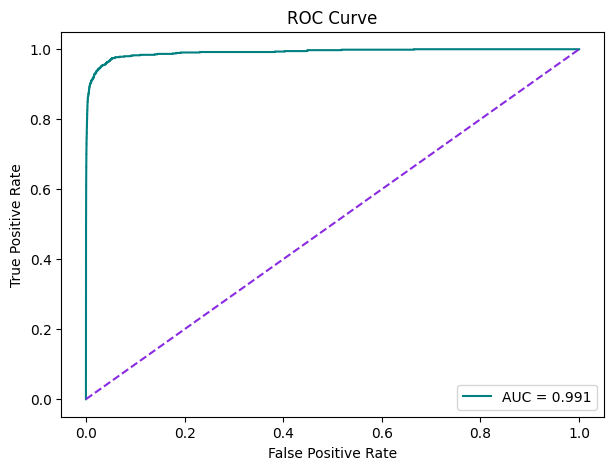

In [21]:
y_probs = model_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds, auc = compute_roc_metrics(y_test, y_probs)
plot_roc_curve(fpr, tpr, auc)

The model achieves an AUC of 99.2%, which is very high. This result is largely driven by the model’s strong ability to correctly identify non-fraudulent transactions.

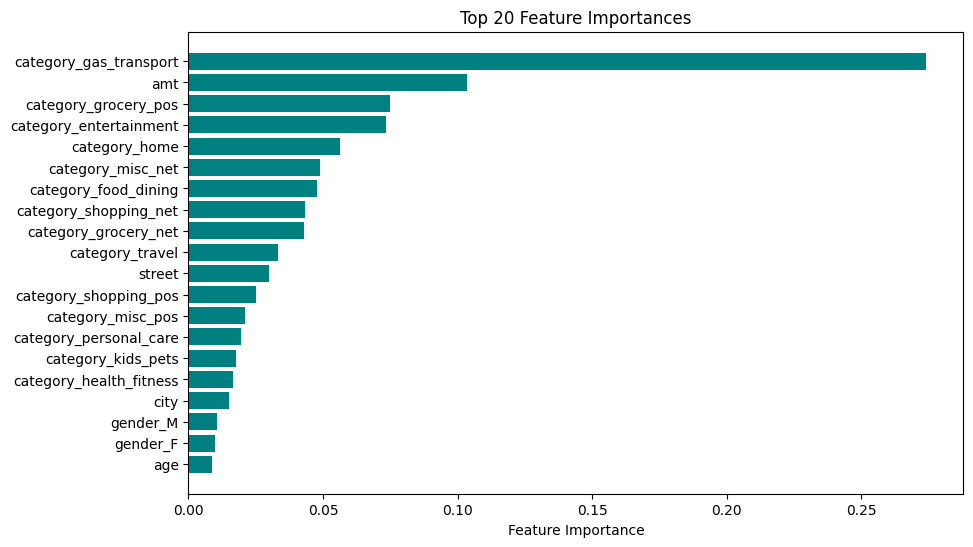

In [22]:
feature_names = get_feature_names(preprocessor, low_card, high_card, numeric_cols)
plot_feature_importance(model_pipeline, feature_names)

In [23]:
shap_values, X_transformed = compute_shap_values(model_pipeline, X_train)

[CV] END model__colsample_bytree=0.75, model__learning_rate=0.01, model__max_depth=8, model__min_child_weight=2, model__n_estimators=200, model__subsample=0.9; total time=  12.6s
[CV] END model__colsample_bytree=0.75, model__learning_rate=0.01, model__max_depth=4, model__min_child_weight=5, model__n_estimators=200, model__subsample=0.9; total time=   8.6s
[CV] END model__colsample_bytree=0.6, model__learning_rate=0.05, model__max_depth=4, model__min_child_weight=2, model__n_estimators=100, model__subsample=0.6; total time=   5.9s
[CV] END model__colsample_bytree=0.75, model__learning_rate=0.05, model__max_depth=4, model__min_child_weight=5, model__n_estimators=100, model__subsample=0.9; total time=   5.7s
[CV] END model__colsample_bytree=0.9, model__learning_rate=0.1, model__max_depth=8, model__min_child_weight=2, model__n_estimators=400, model__subsample=0.75; total time=  24.2s
[CV] END model__colsample_bytree=0.6, model__learning_rate=0.05, model__max_depth=4, model__min_child_weigh

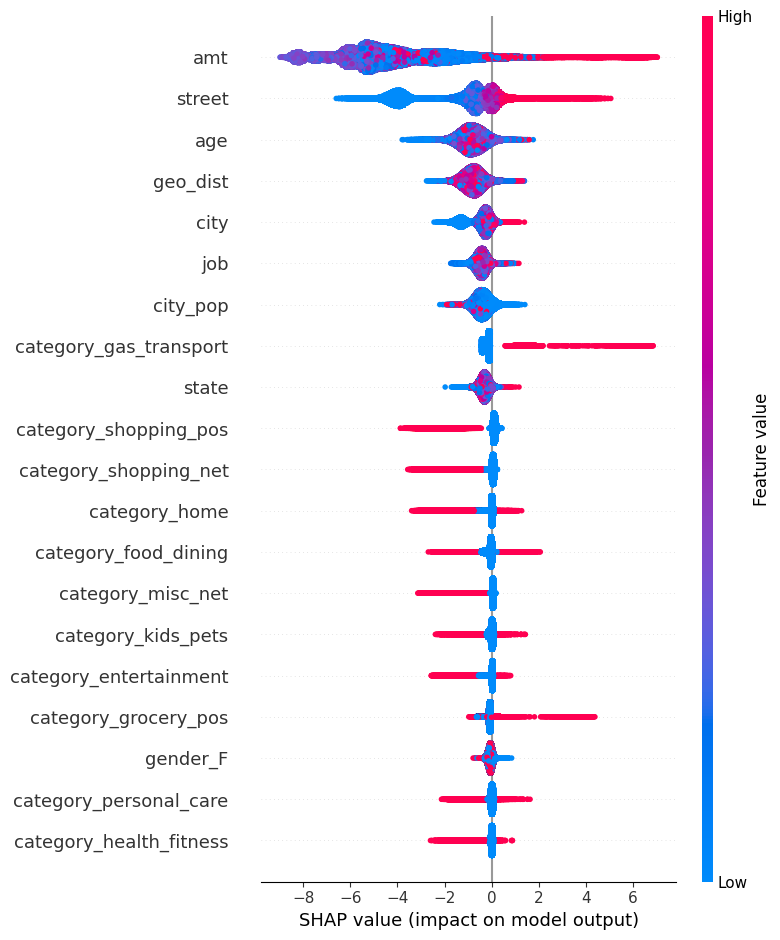

In [36]:
plot_shap_summary(shap_values, X_transformed, feature_names)

Two of the engineered features, age and geographical distance (geo_distance), appear to contribute meaningfully to the model’s predictions, as they rank relatively high in the SHAP feature importance list.

# Model Registration

## Preparing Model Artifacts Using ADS

In [3]:
X_sample = {
    'Unnamed: 0': 684365,
    'trans_date_trans_time': '2019-10-19 11:14:57',
    'cc_num': 581508178315,
    'merchant': 'fraud_Lynch Ltd',
    'category': 'shopping_pos',
    'amt': 131.6,
    'first': 'Michael',
    'last': 'Vargas',
    'gender': 'M',
    'street': '933 Martin Rapids',
    'city': 'Desdemona',
    'state': 'TX',
    'zip': 76445,
    'lat': 32.2819,
    'long': -98.5673,
    'city_pop': 407,
    'job': 'Clothing/textile technologist',
    'dob': '1978-08-08',
    'trans_num': 'd4eabf36041cd28680705e9464315fc0',
    'unix_time': 1350645297,
    'merch_lat': 31.742311,
    'merch_long': -97.657385,
    'merch_zipcode': 76634.0
}

In [38]:
artifact_dir = 'local_path'

In [ ]:
artifact_object = GenericModel(estimator=model_pipeline,artifact_dir=artifact_dir)
artifact_object.prepare(
    inference_conda_env='oci://pub-conda-env@<your_name_sapce>/cpu/generalml_p311_cpu_x86_64_v1/1.0/generalml_p311_cpu_x86_64_v1', # this kernel shuold also run GenericModel method
    inference_python_version="3.11",
    X_sample=X_sample,
    force_overwrite=True
)

Important Note:
- If you specify inference_conda_env=generalml_p311_cpu_x86_64_v1 in the prepare function below, the base version of this environment will be used, which does not include the category_encoders library.
- Therefore, if your scoring depends on category_encoders, you must publish an updated conda environment that includes this library and provide its URL, as shown in the example below.
- For more details on publishing a conda environment, see: https://docs.oracle.com/en-us/iaas/Content/data-science/using/conda_publishs_object.htm

## Customizing the Model Artifacts

We would like to add the feature engineering to the deployment script (rather than ad hoc on the client side). For that we need:
1. Add the create_features logic in the score.py:
A. Copy the create_features function from pre_processing.py and paste it into score.py
B. Modify the predict function to call feature_engineering after pre_inference:
features = pre_inference(data, input_schema_path)
features = create_features(features) # added to apply the customization yhat = post_inference(model.predict(features))
2. Update the deserialize function in score.py
A. add 'import StringIO'
B. Wrap the json_data in the str path:
if "pandas.core.frame.DataFrame" in data_type or isinstance(json_data, str):
return pd.read_json(StringIO(json_data), dtype=fetch_data_type_from_schema(input_schema_path)) # add StringIO for better practice
C. In case you would like to use the same json format as above, please change:
return pd.DataFrame.from_dict(json_data)->return pd.DataFrame.from_dict([json_data])
4. In case of installing new libareries requires to scoring (like category_encoders in our case):
A. Publish your custom conda environment
B. Update the runtime.yaml file by replacnig the INFERENCE_ENV_PATH value with the path to your published custom conda environment. Example:
INFERENCE_ENV_PATH: 'oci://pub-conda-env@<'your_name_space'>/conda_environments/cpu/General Machine Learning for CPUs on Python 3.11/1.0/generalml_p311_cpu_x86_64_v1'
5. Another option to modify score.py is to add the score_py_uri argument to the prepare() method rather than adjusting it ad hoc. The score_py_uri argument points to a pre-created score.py file.

In [45]:
# Reloading in required in order to update the model in the memory for the next steps
artifact_object.reload()

Start loading model.pkl from model directory /home/datascience/code/anomaly_detection/fraud_detection/sklearn_artifact_dir4 ...
Model is successfully loaded.


algorithm: null
artifact_dir:
  /home/datascience/code/anomaly_detection/fraud_detection/sklearn_artifact_dir4:
  - - .model-ignore
    - score.py
    - runtime.yaml
    - model.pkl
framework: null
model_deployment_id: null
model_id: null

# Test model health

Two tests are recommended:

1. Verify method – validates the logic in the score.py file by testing the model’s inference pipeline end-to-end.
2. Introspect – ensures that the model artifact directory is correctly structured and contains all required components.
Both tests must pass before model registration.

In [46]:
artifact_object.verify(X_sample)

Start loading model.pkl from model directory /home/datascience/code/anomaly_detection/fraud_detection/sklearn_artifact_dir4 ...
Model is successfully loaded.


{'prediction': [0]}

In [47]:
artifact_object.introspect()

['.model-ignore', 'score.py', 'runtime.yaml', 'model.pkl']


,Test key,Test name,Result,Message
0,runtime_env_path,Check that field MODEL_DEPLOYMENT.INFERENCE_ENV_PATH is set,Passed,
1,runtime_env_python,Check that field MODEL_DEPLOYMENT.INFERENCE_PYTHON_VERSION is set to a value of 3.6 or higher,Passed,
2,runtime_path_exist,Check that the file path in MODEL_DEPLOYMENT.INFERENCE_ENV_PATH is correct.,Passed,
3,runtime_version,Check that field MODEL_ARTIFACT_VERSION is set to 3.0,Passed,
4,runtime_yaml,"Check that the file ""runtime.yaml"" exists and is in the top level directory of the artifact directory",Passed,
5,score_load_model,Check that load_model() is defined,Passed,
6,score_predict,Check that predict() is defined,Passed,
7,score_predict_arg,Check that all other arguments in predict() are optional and have default values,Passed,
8,score_predict_data,"Check that the only required argument for predict() is named ""data""",Passed,
9,score_py,"Check that the file ""score.py"" exists and is in the top level directory of the artifact directory",Passed,


# Saving and Deploying the Model

In [ ]:
model_id = artifact_object.save(
    display_name="fraud-detection-pipeline",
    description="Fraud detection sklearn pipeline with feature engineering",
    ignore_pending_changes=True)

print(f"Model saved: {model_id}")

In [ ]:
deployed_model = artifact_object.deploy(
    display_name="fraud-detection-pipeline",
    deployment_log_group_id="<log_group_ocid>",
    deployment_predict_log_id="<log_ocid>",
    deployment_instance_shape="VM.Standard.E4.Flex",
    deployment_ocpus=1,
    deployment_memory_in_gbs=16
)

# Scoring

In [4]:
import requests
from oci.auth.signers import get_resource_principals_signer
endpoint='<your_endpoint>

signer = get_resource_principals_signer()
response = requests.post(
    endpoint,
    json=X_sample,
    auth=signer
)
print(response.json())

{'prediction': [0]}
